# XGBoost-malli 2 
Rakenne sama kuin Malli 1:ssä, ilman pitkäaikaissokeria
vertaillaan tuloksia mallien välillä


In [22]:
#!pip install scikit-learn
#!pip install statsmodels
#!pip install shap
#!pip install graphviz


## 1. Kirjastot ja data

In [23]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import plot_importance
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm
from xgboost import plot_tree
from matplotlib import rcParams


In [24]:
df=pd.read_csv("database_original.csv")

In [ ]:
df.drop(columns=['Pitkaaikaissokeri','HDL', 'Insuliini', 'Kokonaiskolesteroli','BMI', 'Vyotaronymparys','Reipas_liikunta(pv/vk)', 'Kavely(pv/vk)'], inplace=True) 
## poistetaan muuttujat, jotka aiheuttavat multikollineaarisuutta ja siten poistettiin logisten resgression ominaisuuden huomioon ottaen sekä pitkäaikasissokeri,a jotta voidaaan arvioida muiden riskitekijöiden ennustekykyä ilman diagnostisesti vahvinta muuttujaa.

## 2. Datan esikäsittely

Korrelaatiomatriisin ja VIF-analyysi — sama valinta 
kuin logistisessa regressiossa mallille 2 -ilman pitkäaikaissokeria. XGBoost ei ole herkkä muuttujien skaalalle, joten RobustScaler jätetään pois mallinnuksesta.


In [26]:
corr_matrix =df.corr()

<Axes: >

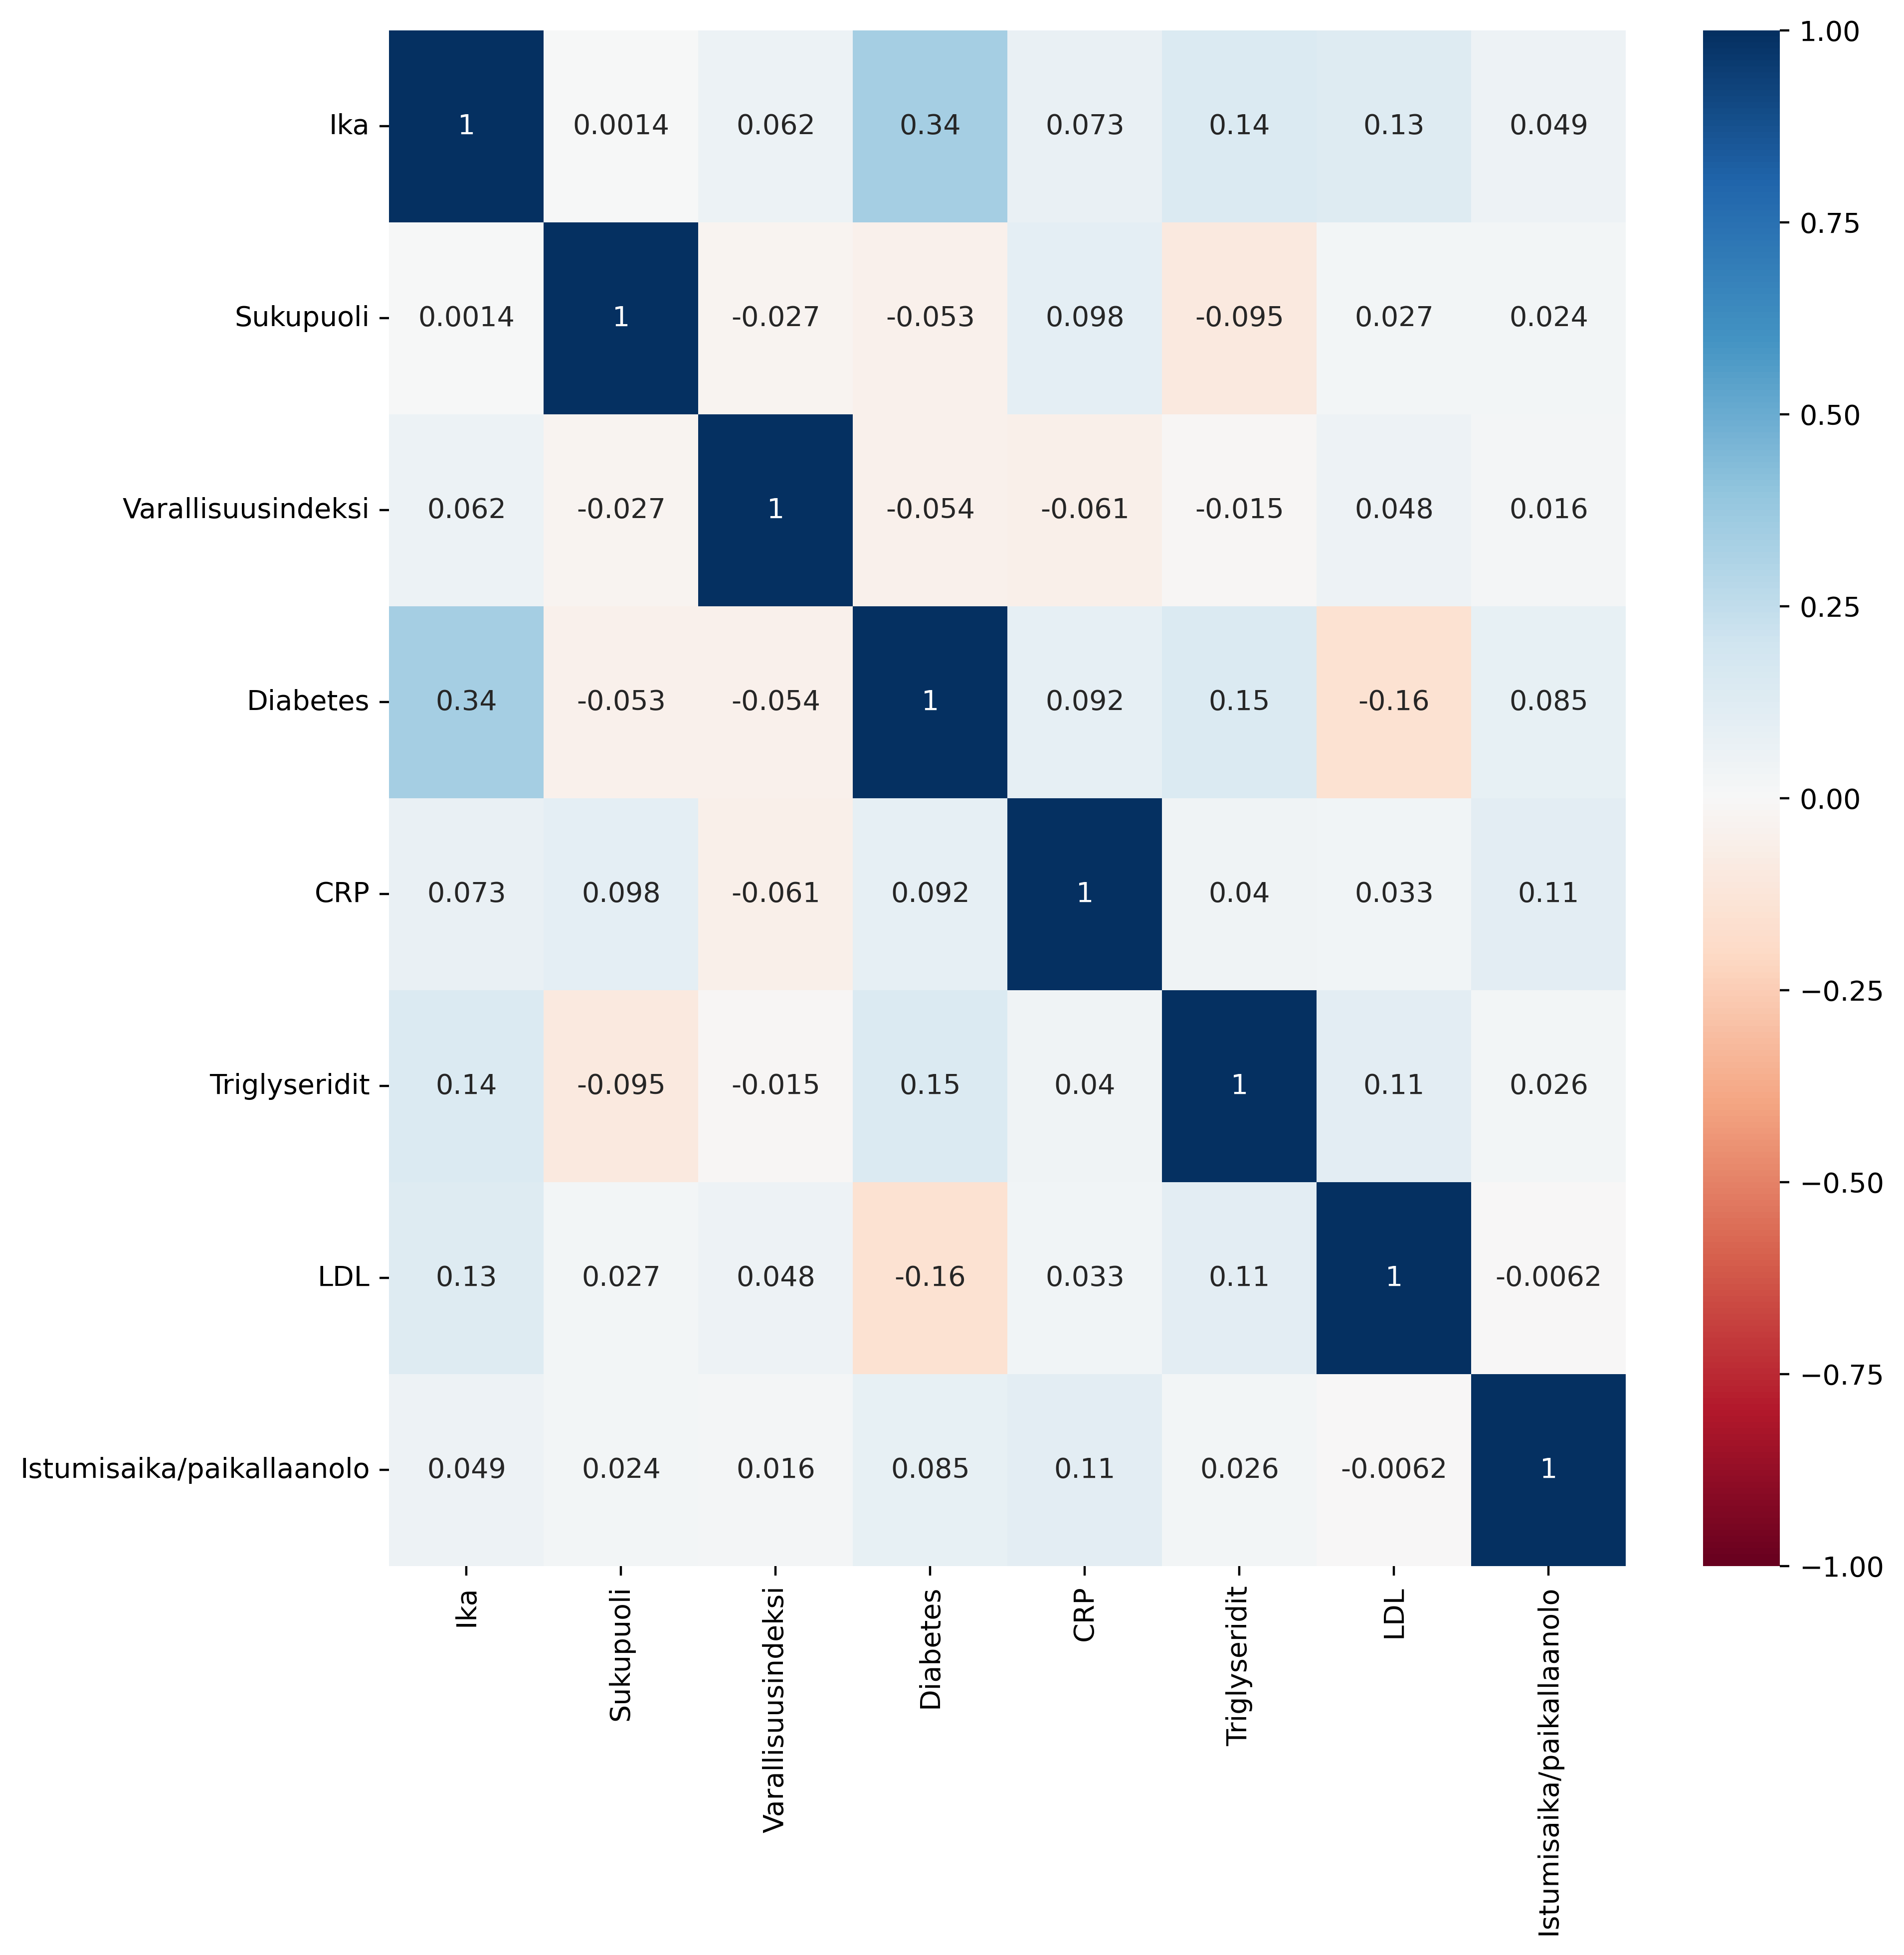

In [43]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, vmin = -1.0, vmax = 1.0, cmap ='RdBu', annot = True)

In [28]:
y = df["Diabetes"] #selitettävä muuttuja
X = df.drop("Diabetes", axis=1) #selitettävät muuttujat


vif_df = pd.DataFrame()
vif_df ["Variables"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df

,Variables,VIF
0,Ika,5.711707
1,Sukupuoli,6.752922
2,Varallisuusindeksi,4.736921
3,CRP,1.351876
4,Triglyseridit,2.182696
5,LDL,7.843116
6,Istumisaika/paikallaanolo,1.423032


In [29]:
X_train, X_test, y_train, y_test =train_test_split( X, y, test_size=0.2, random_state = 42)

In [30]:
y_train.value_counts().round(2)

Diabetes
0    2115
1     357
Name: count, dtype: int64

In [31]:
y_test.value_counts().round(2)

Diabetes
0    538
1     80
Name: count, dtype: int64



Aineistossa on luokkaimbalanssi: 86% ei-diabeetikkoja ja 14% 
diabeetikkoja. Tämä on huomioitu scale_pos_weight-parametrilla.

## 3. Mallin rakentaminen 

Mallia ei tarvitse skaalata niin kuin logistessa regresiossa, koska puupohjaiset menelmät eivät ole herkkiä muutujien mittakaavalle.

Luokkaimbalanssi (86%/14%) korjataan scale_pos_weight-parametrilla, 
joka on XGBoostin vastaava mekanismi logistisen regression 
class_weight='balanced':lle.

scale_pos_weight = enemmistöluokan määrä / vähemmistöluokan määrä
= 2115 / 357 ≈ 5.9



In [32]:
scale = 2115 / 357
xgb = XGBClassifier(scale_pos_weight=scale,n_estimators=300, max_depth=4,learning_rate = 0.05,subsample=0.8, colsample_bytree=0.8, eval_metric= "logloss") #mallin luominen
xgb.fit(X_train, y_train) # mallin kouluttaminen

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

XGBoost-malli koulutettiin käyttäen scale_pos_weight‑parametria (≈ 5.9) korjaamaan luokkien epätasapaino (86 % / 14 %). Tämä vastaa logistisen regression class_weight balanced ‑asetusta ja lisää vähemmistöluokan painoa mallin oppimisessa. Malli rakennettiin 300 matalasyvyisellä puulla (max_depth=4), pienellä oppimisnopeudella (0.05) ja osittaisella näytteenotolla (subsample=0.8, colsample_bytree=0.8) ylisovituksen estämiseksi.

## 4. Mallin arviointi

### 4.1 Ennustetut todennäköisyydet ja jakauma

In [33]:
Y_pred = xgb.predict(X_test) #luokkien ennusteet eli 0= "ei diabetestä" ja 1= "diabetes" -> tarvitaan confusion matrixissa ja accuracyssa
Y_pred_probabilities = xgb.predict_proba(X_test)[:,1] #luokkien todennäköisyydet -> AUC, ROC, riskimallit
Y_pred_probabilities

array([2.15009332e-01, 2.17725545e-01, 4.80575085e-01, 7.51477838e-01,
       8.88315553e-04, 7.90951308e-04, 7.87119940e-02, 2.93749776e-02,
       8.96618739e-02, 8.01768124e-01, 3.99128109e-01, 7.99910165e-04,
       1.58721525e-02, 2.88980398e-02, 3.27619491e-03, 1.26254737e-01,
       7.78997362e-01, 5.28138816e-01, 3.45434574e-03, 4.23326641e-01,
       2.31898739e-03, 4.06313628e-01, 4.16564614e-01, 1.22247194e-03,
       1.69619489e-02, 6.12666607e-01, 3.93552333e-03, 9.58227277e-01,
       3.97585005e-01, 4.36998814e-01, 6.45968714e-04, 1.25547182e-02,
       1.21335961e-01, 5.75154147e-04, 7.59415445e-04, 2.86001340e-02,
       2.43252655e-03, 1.94759611e-02, 8.28672767e-01, 1.07873045e-03,
       3.49785611e-02, 2.98345607e-04, 1.61833063e-01, 9.51714348e-03,
       1.34368450e-03, 8.01905870e-01, 2.66962290e-01, 4.18486446e-03,
       8.56259644e-01, 2.05457821e-01, 3.61314923e-01, 2.48485491e-01,
       8.33467662e-01, 6.01937294e-01, 3.65880698e-01, 9.04536843e-01,
      

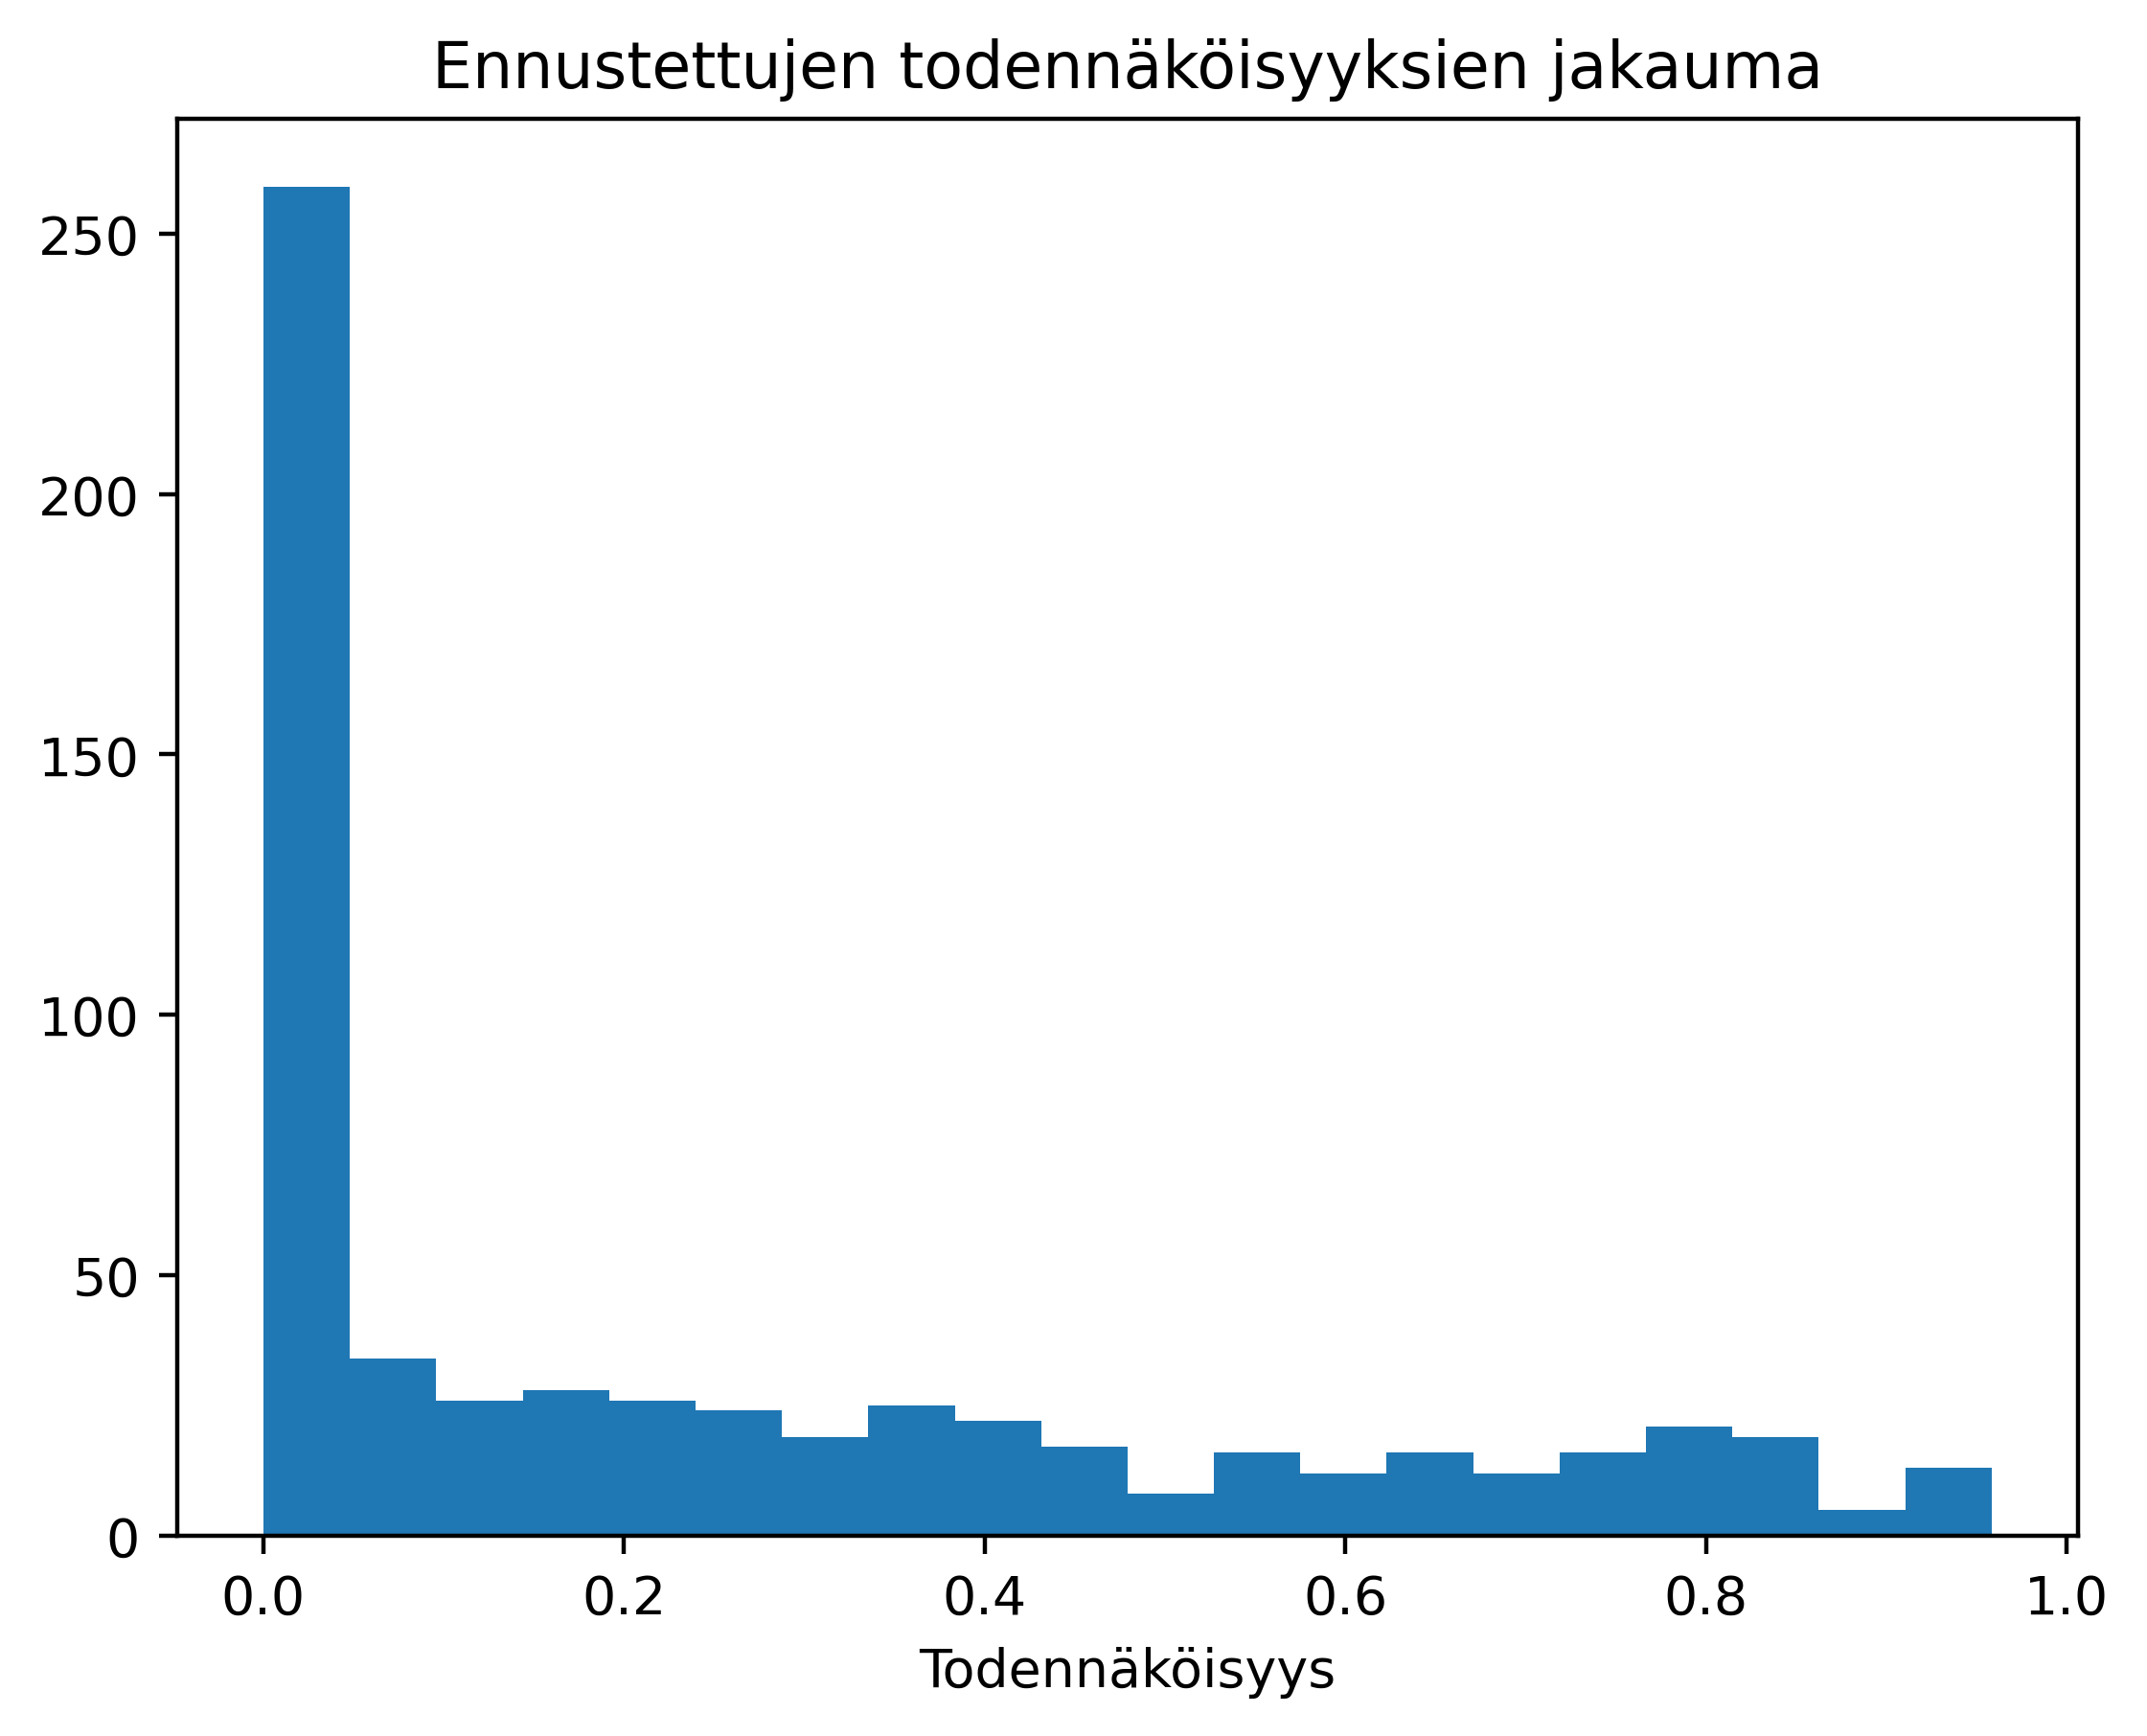

In [34]:
plt.hist(Y_pred_probabilities, bins=20)
plt.xlabel('Todennäköisyys')
plt.title('Ennustettujen todennäköisyyksien jakauma')
plt.show()



Histogrammi näyttää mallin antamien todennäköisyysennusteiden 
jakauman. Suurin piikki on lähellä nollaa — suurimmalle osalle 
testijoukon henkilöistä malli ennustaa matalaa diabetesriskiä, 
mikä vastaa aineiston luokkajakaumaa (86% ei-diabeetikkoja).

Jakauma on kuitenkin selvästi tasaisempi kuin Malli 1:ssä — 
arvoja löytyy koko väliltä 0.0–1.0. Tämä kertoo että ilman 
pitkäaikaissokeria malli on epävarmempi ennusteissaan, mikä 
näkyy myös korkeampana log lossina (0.376 vs 0.176).

Kliinisessä seulonnassa tämä on hyödyllistä — malli ei luokittele 
henkilöitä mustavalkoisesti vaan tuottaa riskiryhmittelyä koko 
todennäköisyysasteikolla. Tämä ei yksin vielä kerro mallin hyvyydestä, 
vaan jakaumaa pitää tulkita yhdessä ROC:n, recallin ja confusion matrixin kanssa.

### 4.2 Log Loss
Mittaa kuinka tarkasti ja varmasti malli antaa todennäköisyyksiä.
Mitä lähempänä 0 sitä parempi:
- alle 0.3 → erinomainen
- 0.3–0.5 → hyvä
- yli 0.7 → heikko


In [35]:
logloss = log_loss(y_test, Y_pred_probabilities)
print(logloss)

0.3756214517644992


Log loss 0.376 viittaa siihen, että mallin todennäköisyysennusteet ovat kohtuullisen hyviä, mutta selvästi epävarmempia kuin mallissa 1. Tämä on odotettua, koska pitkäaikaissokeri poistettiin.

### 4.3 AUC ja ROC-käyrä
ROC-käyrä kuvaa mallin erottelukykyä eri kynnysarvoilla.
AUC mittaa mallin kykyä erotella diabeetikot ei-diabeetikoista 
eri päätöskynnysarvoilla. Arvo 1.0 on täydellinen ja 0.5 
vastaa satunnaista arvausta.

- 0.9–1.0 → erinomainen
- 0.8–0.9 → hyvä  
- 0.7–0.8 → kohtalainen

In [36]:
auc = roc_auc_score(y_test, Y_pred_probabilities)
print("AUC", auc)

AUC 0.8476998141263941


AUC 0.848 tarkoittaa, että malli erottaa diabeetikot ja ei-diabeetikot melko hyvin.

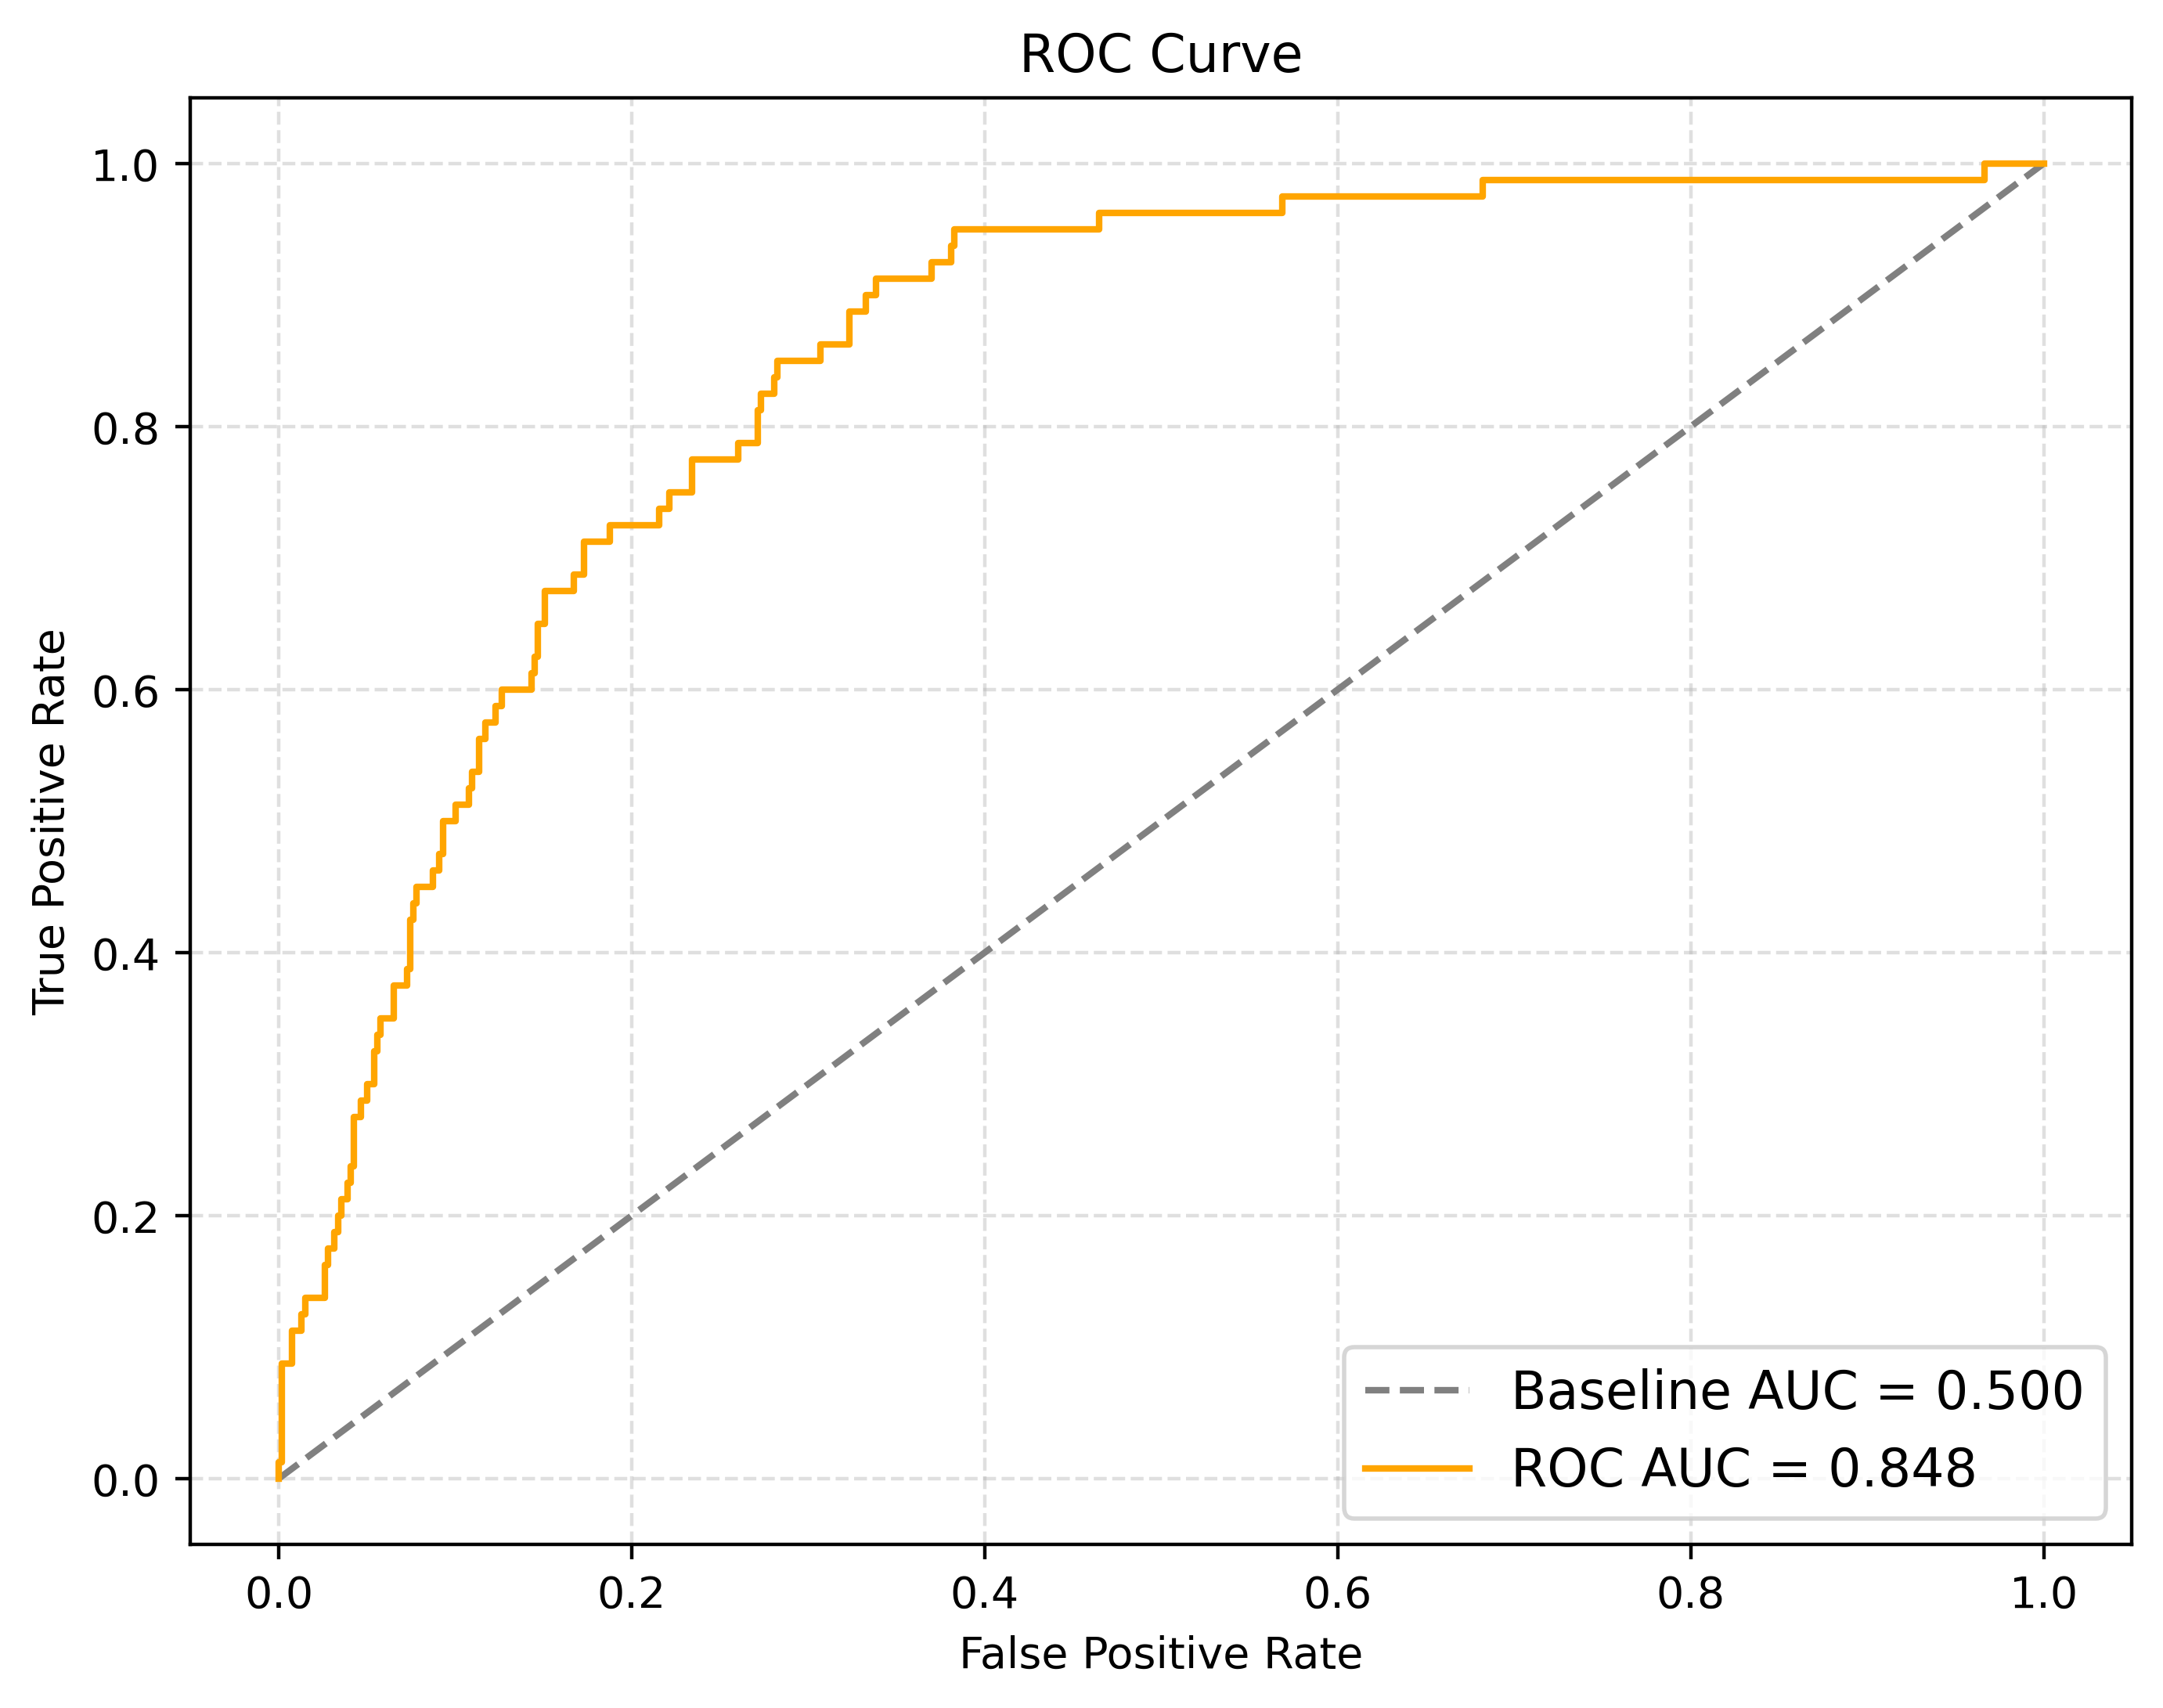

In [37]:
baseline_probs = [0 for _ in range(len(y_test))] # baseline-malli

Y_pred_probabilities = xgb.predict_proba(X_test)[:, 1] # mallin todennäköisyydet luokalle 1


baseline_auc = roc_auc_score(y_test, baseline_probs) # baseline AUC
pc_auc = roc_auc_score(y_test, Y_pred_probabilities) #predict_probalities AUC

# ROC-käyrän pisteet
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_probs)
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_probabilities, drop_intermediate=False)

# ROC-käyrä
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr, baseline_tpr,
    linestyle='--', color='gray',
    label=f'Baseline AUC = {baseline_auc:.3f}'
)

plt.plot(
    fpr, tpr,
    color='orange',
    label=f'ROC AUC = {pc_auc:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

ROC-käyrä nousee vasempaan yläkulmaan, mikä kertoo hyvästä 
herkkyydestä melko pienellä väärän positiivisen määrällä.

### 4.4 Confusion Matrix ja Classification Report
Binääriset ennusteet arvioidaan confusion matrixin avulla.
Kliinisessä kontekstissa recall on tärkein mittari — 
väärä negatiivinen (diabeetikko jää tunnistamatta) on 
haitallisempi kuin väärä positiivinen.

In [38]:
cm = confusion_matrix(y_test, Y_pred)
print("Confusion matrix:\n",cm)
accuracy = accuracy_score(y_test, Y_pred)
print("\nAccuracy = %.3f" % (accuracy)) 
print("\nClassification report\n")
print(classification_report(y_test, Y_pred))

Confusion matrix:
 [[457  81]
 [ 27  53]]

Accuracy = 0.825

Classification report

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       538
           1       0.40      0.66      0.50        80

    accuracy                           0.83       618
   macro avg       0.67      0.76      0.69       618
weighted avg       0.87      0.83      0.84       618



Malli tunnistaa 66 % diabeetikoista oikein, mutta precision positiiviselle luokalle on vain 0.40. Tämä tarkoittaa, että mallin ennustamista diabetestapauksista suuri osa on virheellisiä positiivisia. Seulontatilanteessa tämä voi olla hyväksyttävää, jos tärkeämpää on löytää mahdollisimman moni riskihenkilö kuin minimoida turhat hälytykset. tulokset ovat selvästi epätarkempia kuin mallin 1 tulokset.

### 4.5 Feature Importance

Gain-tyyppinen tärkeys kertoo kuinka paljon kukin muuttuja 
parantaa mallin ennustekykyä päätöspuun haarautumiskohdissa 
keskimäärin. Mitä suurempi gain, sitä tärkeämpi muuttuja 
on mallille.

In [39]:

importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))



Ika                          0.330591
LDL                          0.167692
Triglyseridit                0.127551
CRP                          0.101754
Varallisuusindeksi           0.100432
Sukupuoli                    0.091412
Istumisaika/paikallaanolo    0.080567
dtype: float32


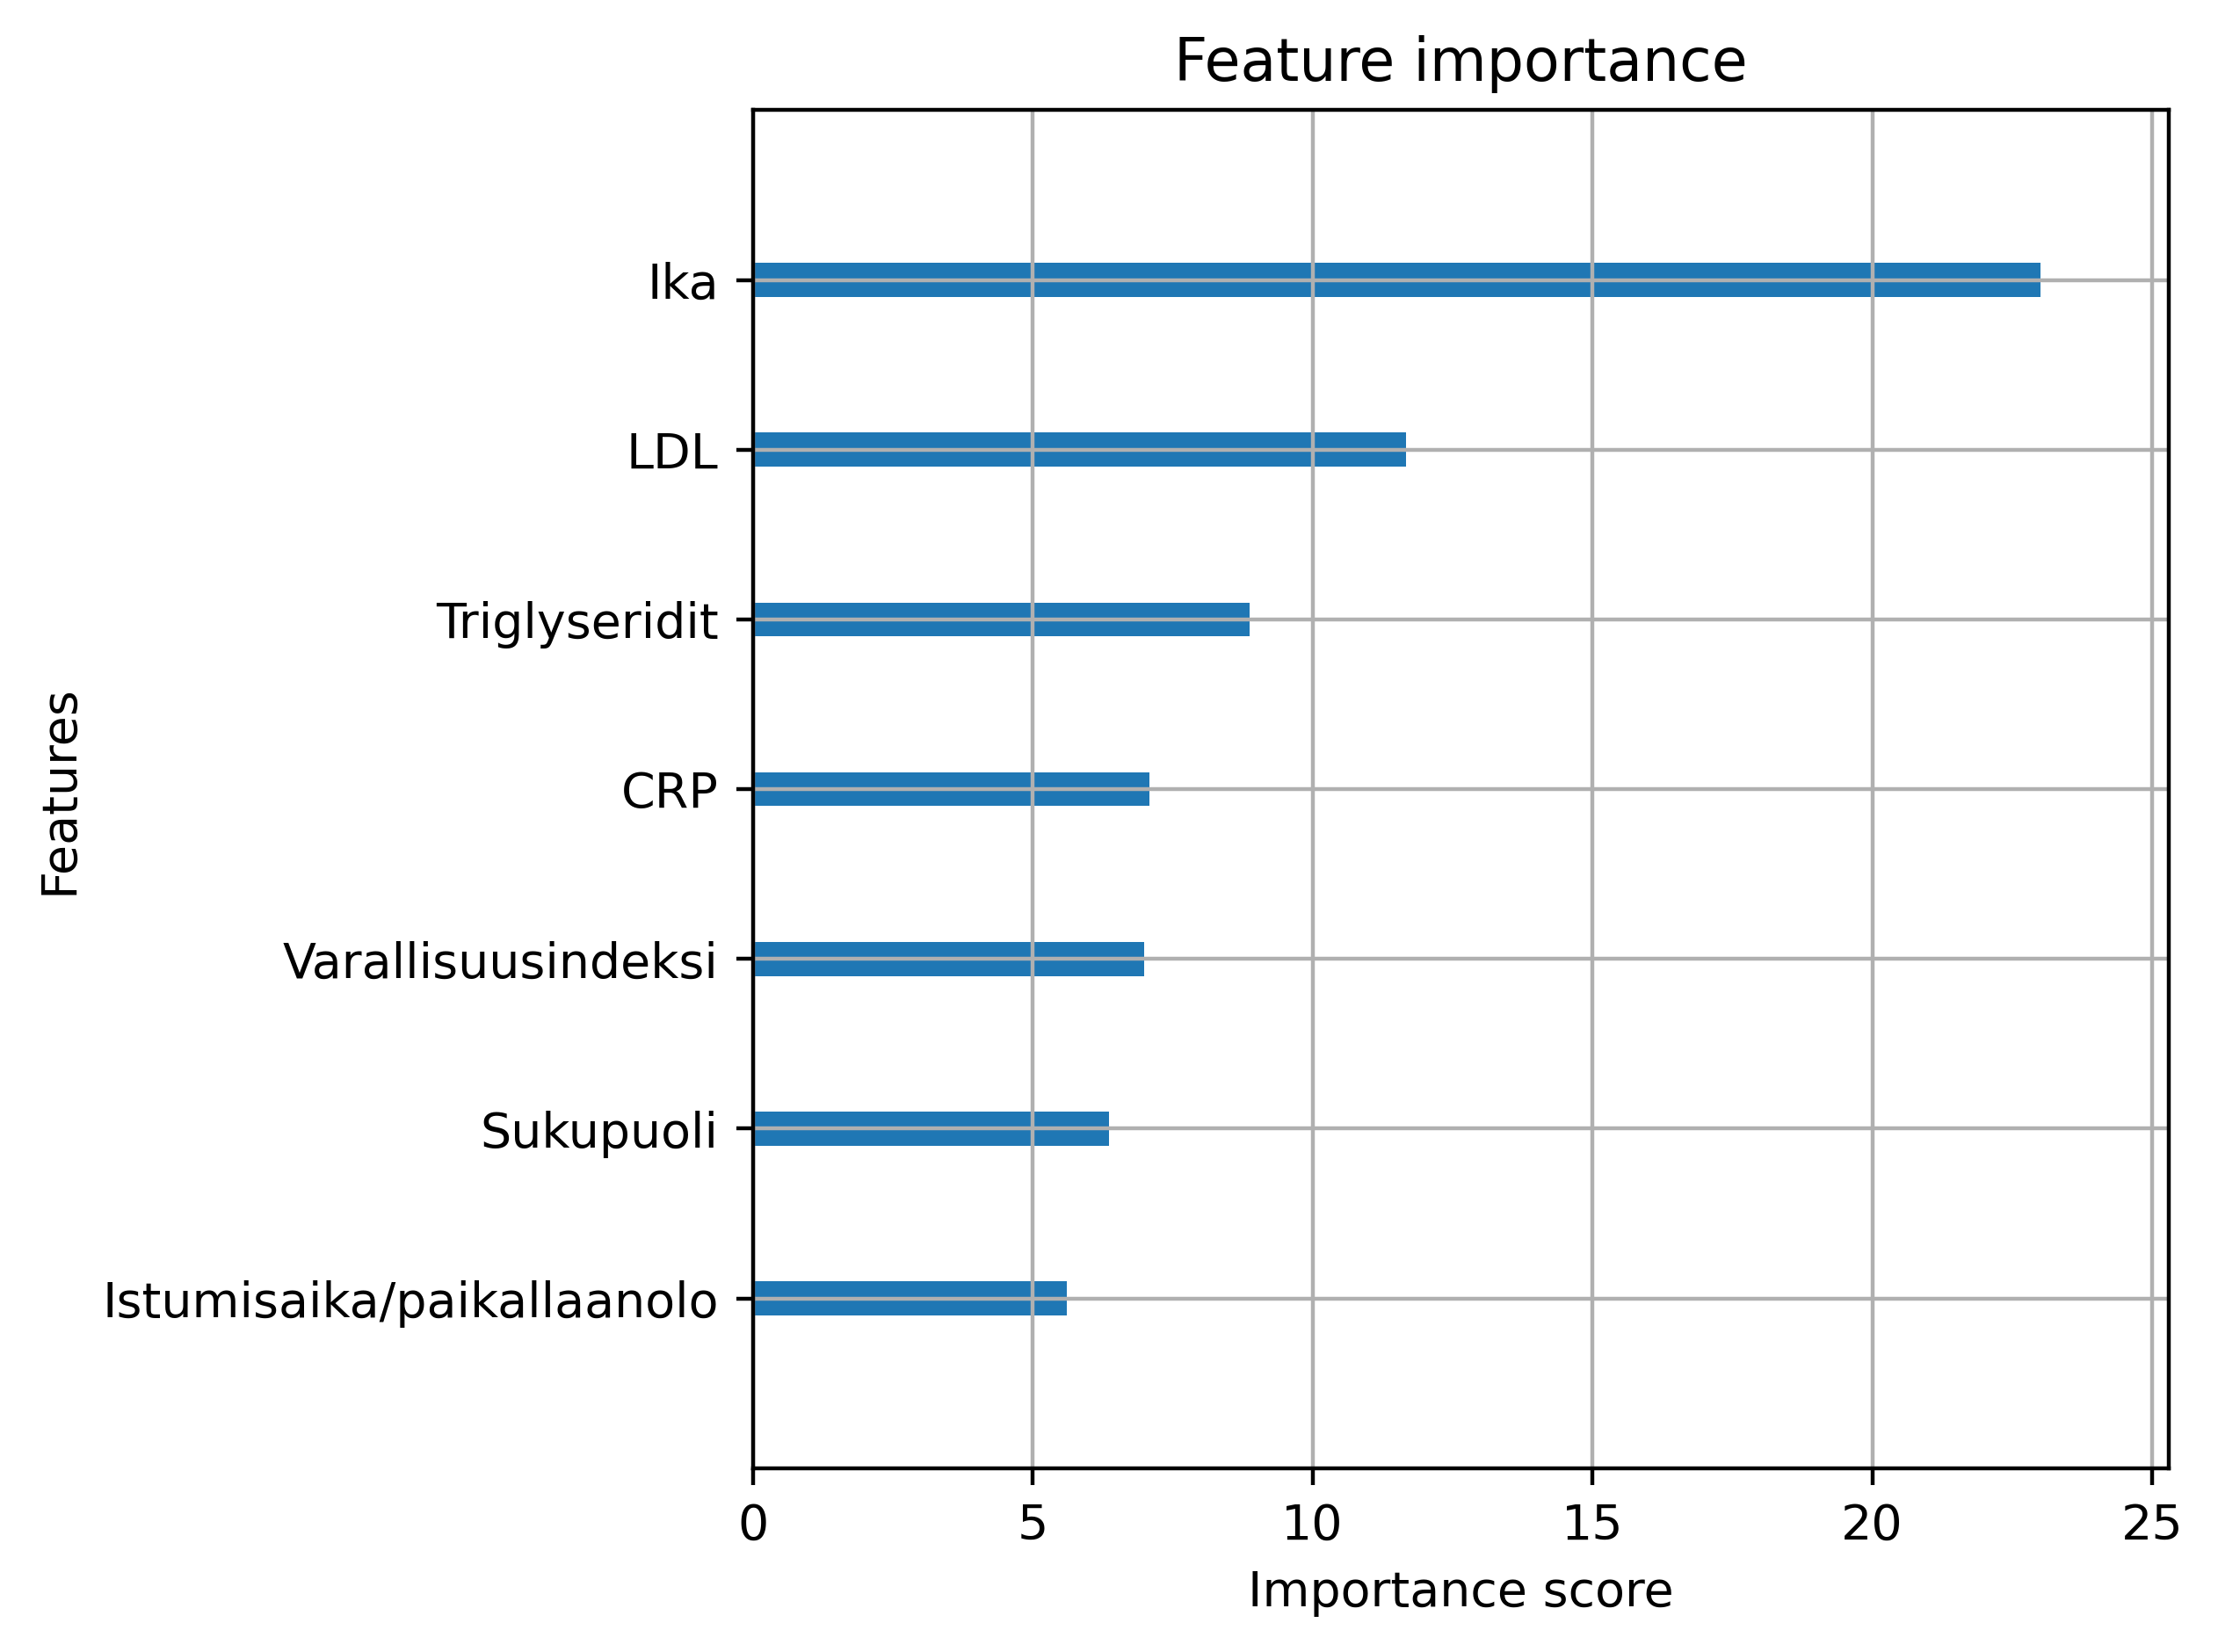

In [40]:
plot_importance(xgb, importance_type='gain',  max_num_features=8,show_values=False)
plt.tight_layout()
plt.show()

Ilman pitkäaikaissokeria ikä nousee selvästi tärkeimmäksi 
muuttujaksi (gain 0.33) — yli 2-kertainen seuraavaan 
muuttujaan (LDL, 0.17) verrattuna.

Tärkeys jakautuu tasaisemmin kuin Malli 1:ssä — yksikään 
muuttuja ei dominoi ylivoimaisesti. LDL (0.17), triglyseridit 
(0.13), CRP (0.10) ja varallisuusindeksi (0.10) ovat 
seuraavaksi tärkeimmät. Sukupuoli ja istumisaika jäävät 
pienimmälle painolle (0.08–0.09).

### 4.6 SHAP-analyysi 
Analyysi selittää yksittäisten muuttujien vaikutuksen mallin päätöksiin sekä suunnan että 
voimakkuuden osalta. Toisin kuin feature importance, SHAP 
kertoo myös lisääkö vai vähentääkö muuttujan arvo 
diabetesriskiä.

tulkinta:

SHAP-kuvassa punaiset pisteet kuvaavat korkeita muuttuja-arvoja ja siniset matalia. 
Oikealle siirtyvät arvot kasvattavat diabeteksen ennustettua todennäköisyyttä ja vasemmalle siirtyvät pienentävät sitä.


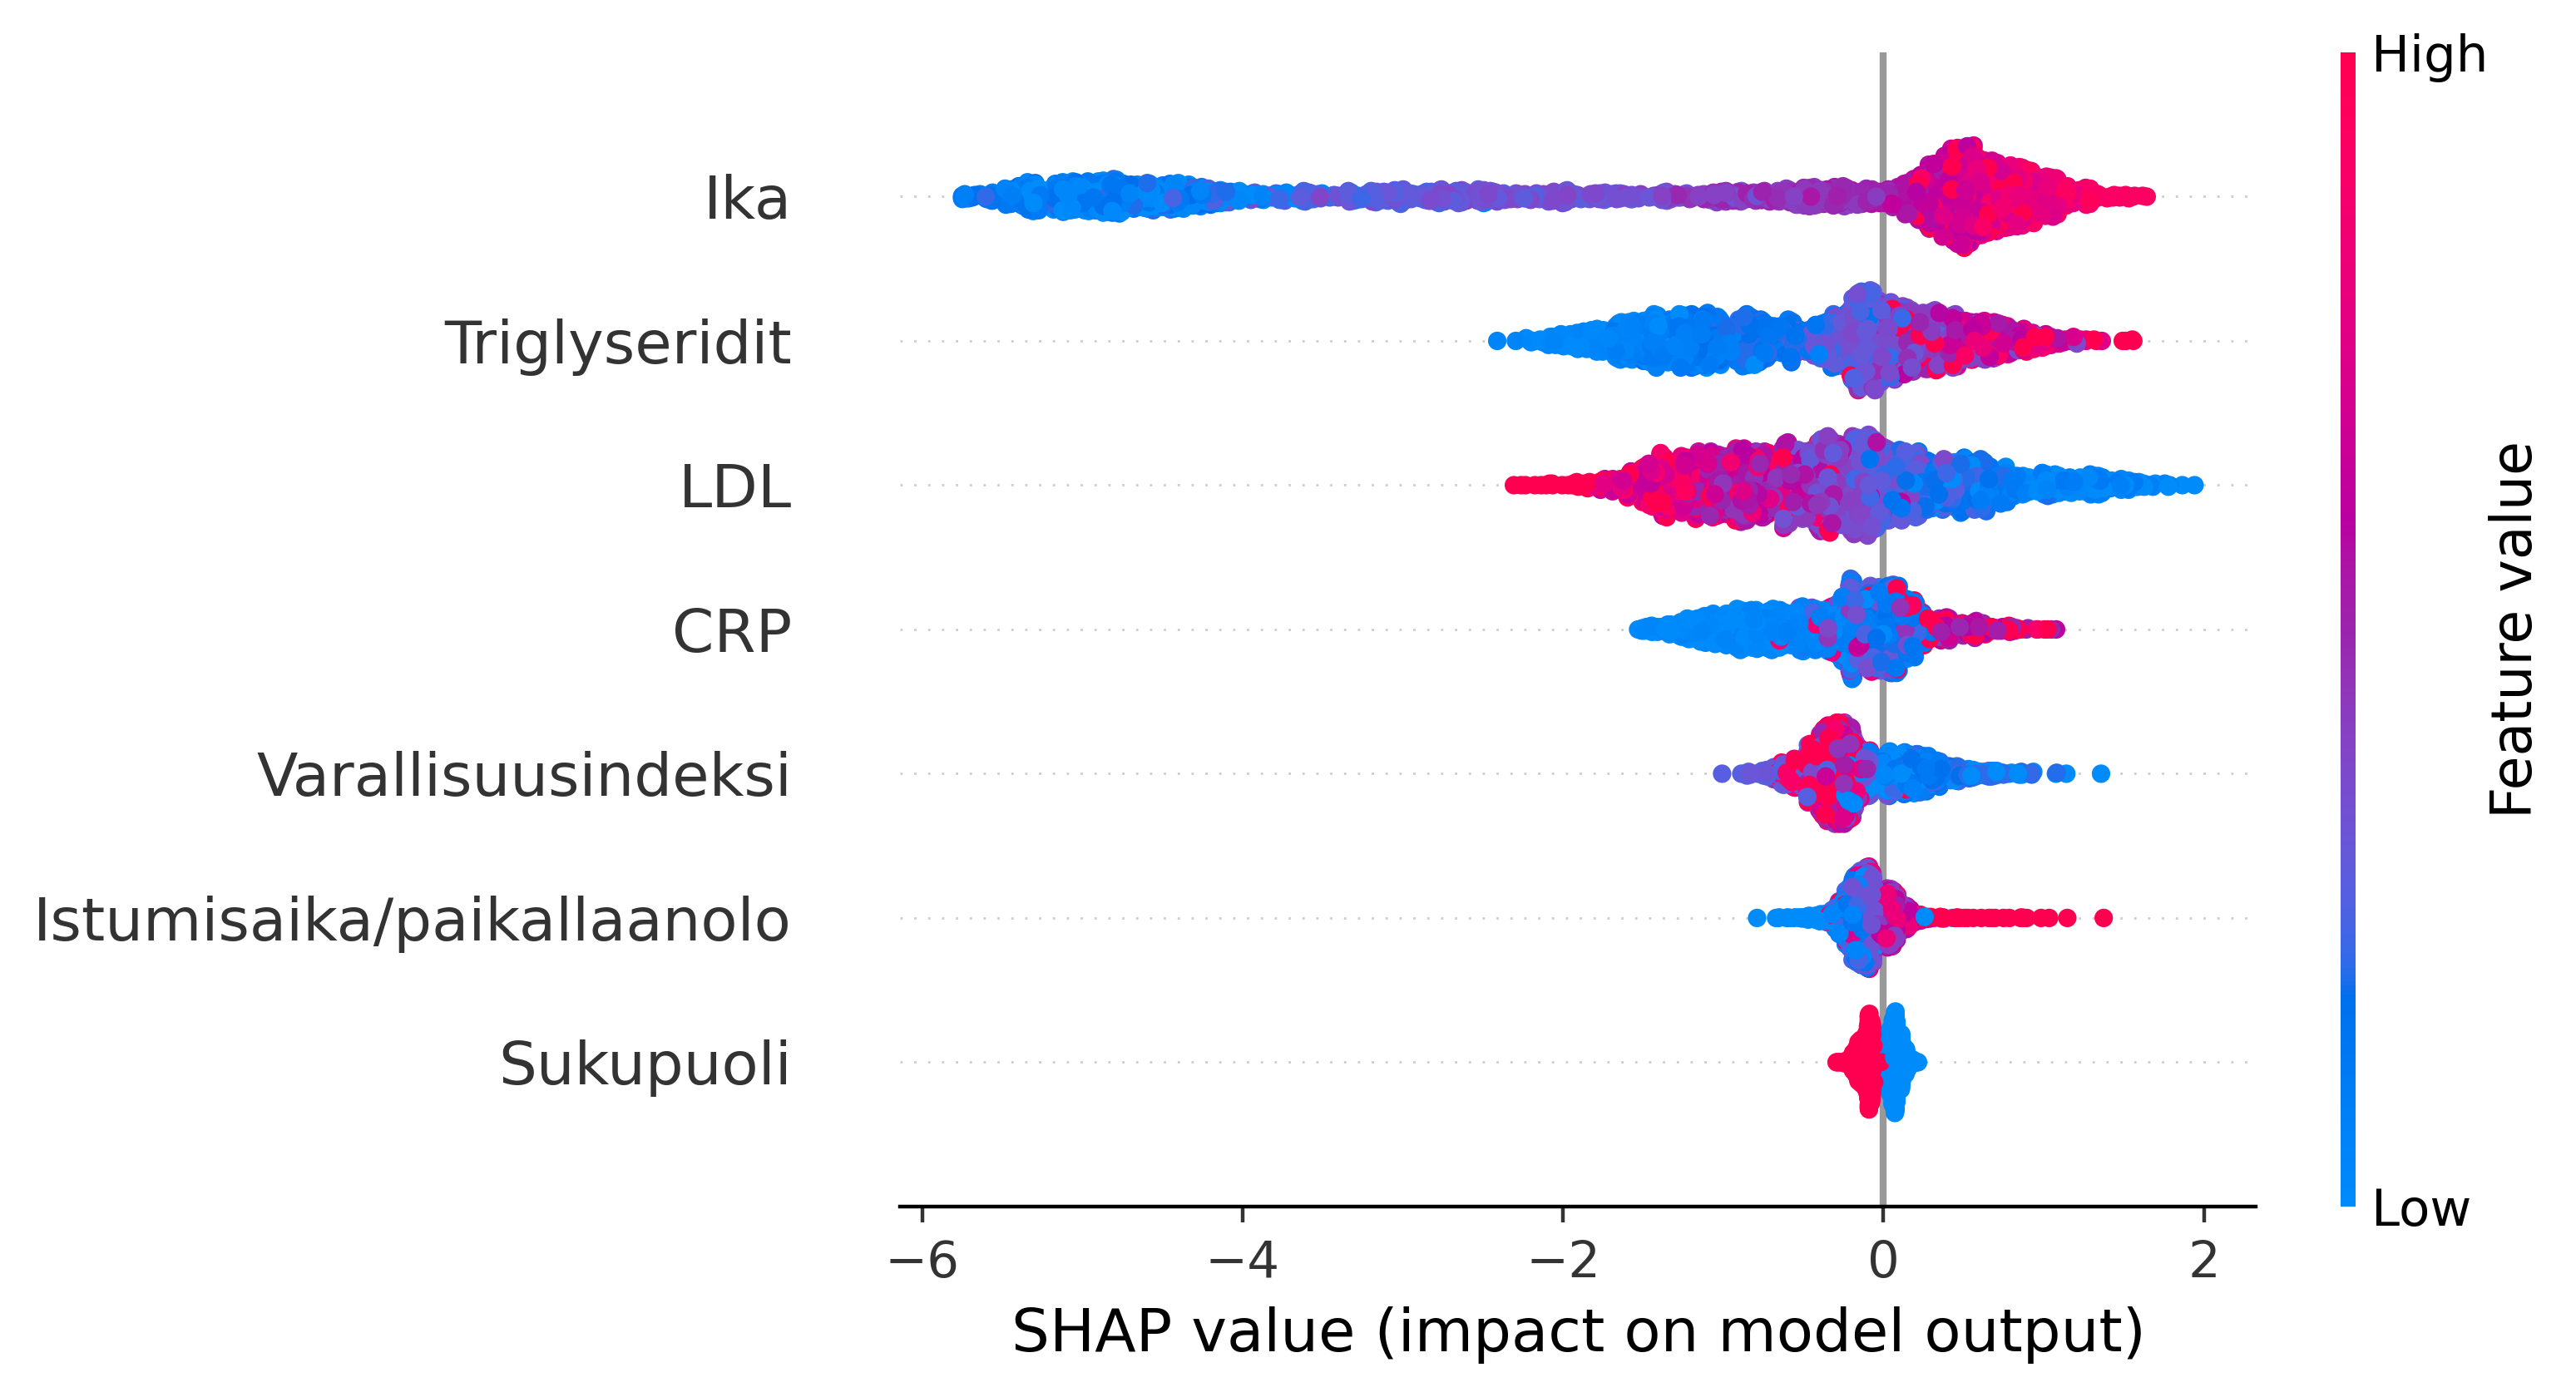

In [41]:
explainer = shap.TreeExplainer(xgb) #Mitkä muutujat vaikuttavat mallin päätöksiin ja miten.
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)




SHAP-arvot vahvistavat feature importancen tulokset ja kertovat 
lisäksi vaikutuksen suunnan:

-Ikä: selkeästi tärkeä muuttuja ilman pitkäaikaissokeria. Matala ikä 
(sininen) vähentää riskiä voimakkaasti (arvot jopa -6 asti), 
korkea ikä (punainen) lisää riskiä — selkeä ja looginen yhteys.

-Triglyseridit: Korkeat arvot (punainen) lisäävät riskiä 
lievästi oikealle — linjassa metabolisen oireyhtymän kanssa.

-LDL Käänteinen kuvio säilyy — jakauma on laaja mutta 
painottuu oikealle sinisillä arvoilla, mikä viittaa että 
matala LDL lisää riskiä. Biologisesti yllättävä (voi 
heijastaa kolesterolilääkityksen vaikutusta aineistossa.)

-CRP: ohonneet arvot lisäävät riskiä lievästi — linjassa 
tulehduksen yhteydestä diabetekseen.

-Varallisuusindeksi SHAP-arvot painottuvat hieman 
positiiviselle puolelle — matala varallisuus voi lisätä 
riskiä lievästi.

-Istumisaika ja sukupuoli: SHAP-arvot keskittyvät lähes 
nollaan — vaikutus on pieni tässä mallissa.

Ilman pitkäaikaissokeria ikä nousee dominoivaksi muuttujaksi 
ja sen SHAP-hajonta kasvaa merkittävästi — erityisesti 
negatiivisella puolella (jopa -6 asti vs Malli 1:ssä -2 asti). 
Tämä kertoo että nuori ikä on vahva suojaava tekijä kun 
pitkäaikaissokeri ei ohjaa mallin päätöksiä.

Triglyseridit nousevat toiseksi tärkeimmäksi Malli 2:ssa, 
kun taas Malli 1:ssä LDL oli toisena. Muuttujien 
vaikutussuunnat säilyvät pääosin samoina molemmissa malleissa 
— LDL:n käänteinen yhteys ja sukupuolen vähäinen merkitys 
toistuvat kummassakin. 

### 4.7 Päätöspuuvisualisointi
XGBoostin yksittäiset päätöspuut visualisoidaan havainnollistamaan 
mallin päätöksentekoprosessia. äätöspuu havainnollistaa yhden yksittäisen boosting-vaiheen rakennetta, 
mutta sitä ei tule tulkita koko mallin päätöksentekona. XGBoostin ennuste muodostuu kaikkien puiden yhteisvaikutuksesta.

In [42]:
rcParams['figure.dpi'] = 400
fig, ax = plt.subplots(figsize=(80, 50))
plot_tree(xgb, tree_idx=6, ax=ax)
plt.show()

Ilman pitkäaikaissokeria ensimmäinen jako tehdään iän perusteella 
(< 41) — vahvistaa iän dominoivan roolin Malli 2:ssa. Seuraavilla 
tasoilla käytetään triglyseriditä, LDL:ää ja istumisaikaa 
tarkentamaan ennustetta.